In [2]:
# 1. IMPORTS & SETUP
# ==============================================================================
import os
import cv2
import time
import zipfile
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Define device for RTX 4060 / RTX 3060
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# ==============================================================================
# 2. DATA LOADING & PREPROCESSING (CPU)
# ==============================================================================

# Use raw strings (r"...") to prevent Windows path errors
TRAIN_TUMOR_PATH = r"C:\Users\pooja\Downloads\Dataset\Training\tumor"
TRAIN_NO_TUMOR_PATH = r"C:\Users\pooja\Downloads\Dataset\Training\no tumor"
TEST_TUMOR_PATH = r"C:\Users\pooja\Downloads\Dataset\Testing\tumor"
TEST_NO_TUMOR_PATH = r"C:\Users\pooja\Downloads\Dataset\Testing\no tumor"

def load_images(path, label):
    images, labels = [], []
    if not os.path.exists(path):
        print(f"Warning: Path not found - {path}")
        return images, labels
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        images.append(img)
        labels.append(label)
    return images, labels

# Load Training Data
train_tumor_imgs, train_tumor_lbls = load_images(TRAIN_TUMOR_PATH, 1)
train_no_tumor_imgs, train_no_tumor_lbls = load_images(TRAIN_NO_TUMOR_PATH, 0)

# Load Testing Data
test_tumor_imgs, test_tumor_lbls = load_images(TEST_TUMOR_PATH, 1)
test_no_tumor_imgs, test_no_tumor_lbls = load_images(TEST_NO_TUMOR_PATH, 0)

# Combine everything together into a single dataset
X = train_tumor_imgs + train_no_tumor_imgs + test_tumor_imgs + test_no_tumor_imgs
y = train_tumor_lbls + train_no_tumor_lbls + test_tumor_lbls + test_no_tumor_lbls

print(f"Total images loaded: {len(X)}")
print(f"- Training Tumor: {len(train_tumor_imgs)}")
print(f"- Training No Tumor: {len(train_no_tumor_imgs)}")
print(f"- Testing Tumor: {len(test_tumor_imgs)}")
print(f"- Testing No Tumor: {len(test_no_tumor_imgs)}")

def preprocess(images, size=(128,128)):
    processed = []
    for img in images:
        img = cv2.resize(img, size)
        img = img / 255.0
        # Optional: Gaussian blur for noise reduction
        img = cv2.GaussianBlur(img, (5,5), 0)
        processed.append(img)
    return np.array(processed)

X_prep = preprocess(X) if len(X) > 0 else np.random.rand(100, 128, 128)
print("Final dataset shape:", X_prep.shape)

Total images loaded: 10093
- Training Tumor: 4117
- Training No Tumor: 4160
- Testing Tumor: 906
- Testing No Tumor: 910
Final dataset shape: (10093, 128, 128)


In [4]:
# 3. GPU BATCH PREPARATION & K-SPACE SIMULATION
# ==============================================================================
BATCH_SIZE = 64 # Adjust based on your VRAM (RTX 3060/4060 can easily handle 64-128)
actual_batch_size = min(BATCH_SIZE, len(X_prep))

# Move a batch of images to the GPU
img_batch = torch.tensor(X_prep[:actual_batch_size], dtype=torch.float32, device=device)

# Simulate K-Space for the entire batch (use dim=(-2, -1) for 2D spatial FFT)
k_space_batch = torch.fft.fftshift(torch.fft.fft2(img_batch), dim=(-2, -1))

# Create Mask (Center 25%)
mask = torch.zeros((128, 128), device=device)
center_fraction = 0.25
c = int(128 * center_fraction)
mask[64-c//2:64+c//2, :] = 1

# Apply Mask to the entire batch (Broadcasting)
k_under_batch = k_space_batch * mask

# Add Noise
noise = 0.08 * (torch.randn_like(k_under_batch) + 1j * torch.randn_like(k_under_batch))
k_noisy_batch = k_under_batch + noise

# Original image (for metrics comparison later)
orig_img_cpu = img_batch[0].cpu().numpy()

# Helper function to print GPU metrics
def print_gpu_metrics(method_name, start_time, end_time, batch_size):
    total_time_sec = end_time - start_time
    total_time_ms = total_time_sec * 1000
    throughput = batch_size / total_time_sec if total_time_sec > 0 else 0
    peak_mem = torch.cuda.max_memory_allocated(device) / (1024 * 1024)
    
    print(f"\n--- {method_name} (GPU) ---")
    print(f"Batch Time (ms): {total_time_ms:.2f}")
    print(f"GPU Reconstruction Time (ms): {total_time_ms:.2f}")
    print(f"Peak GPU Memory Usage (MB): {peak_mem:.2f}")
    print(f"Peak GPU Memory (MB): {peak_mem:.2f}")
    print(f"Throughput (images/sec): {throughput:.2f}")

In [5]:
# 4. ZERO FILLED RECONSTRUCTION (ZFR) - GPU
# ==============================================================================
torch.cuda.reset_peak_memory_stats(device)
torch.cuda.synchronize() # Wait for all GPU tasks to finish before timing
start = time.time()

recon_zfr_batch = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(k_noisy_batch, dim=(-2, -1))))

torch.cuda.synchronize() # Wait for GPU processing to complete
end = time.time()

print_gpu_metrics("Zero Filled Reconstruction (ZFR)", start, end, actual_batch_size)

zfr_img_cpu = recon_zfr_batch[0].cpu().numpy()
print(f"ZFR PSNR: {peak_signal_noise_ratio(orig_img_cpu, zfr_img_cpu, data_range=1.0):.2f}")
print(f"ZFR SSIM: {structural_similarity(orig_img_cpu, zfr_img_cpu, data_range=1.0):.4f}")



--- Zero Filled Reconstruction (ZFR) (GPU) ---
Batch Time (ms): 492.98
GPU Reconstruction Time (ms): 492.98
Peak GPU Memory Usage (MB): 56.06
Peak GPU Memory (MB): 56.06
Throughput (images/sec): 129.82
ZFR PSNR: 38.02
ZFR SSIM: 0.9719


In [6]:
# 5. CONJUGATE GRADIENT (CG) - GPU
# ==============================================================================
def A(x):
    return mask * torch.fft.fftshift(torch.fft.fft2(x), dim=(-2, -1))

def AH(x):
    return torch.abs(torch.fft.ifft2(torch.fft.ifftshift(mask * x, dim=(-2, -1))))

b = AH(k_noisy_batch)
x = torch.zeros_like(b)

r = b - AH(A(x))
p = r.clone()
# Keep batch dimension independent by summing over spatial dims (-2, -1)
rsold = torch.sum(r * r, dim=(-2, -1), keepdim=True)

cg_iters = 10

torch.cuda.reset_peak_memory_stats(device)
torch.cuda.synchronize()
start = time.time()

for _ in range(cg_iters):
    Ap = AH(A(p))
    alpha = rsold / torch.sum(p * Ap, dim=(-2, -1), keepdim=True)
    x = x + alpha * p
    r = r - alpha * Ap
    rsnew = torch.sum(r * r, dim=(-2, -1), keepdim=True)
    
    # Check convergence based on max error in batch
    if torch.max(torch.sqrt(rsnew)) < 1e-6:
        break
        
    p = r + (rsnew / rsold) * p
    rsold = rsnew

recon_cg_batch = x

torch.cuda.synchronize()
end = time.time()

print_gpu_metrics("Conjugate Gradient (CG)", start, end, actual_batch_size)

cg_img_cpu = recon_cg_batch[0].cpu().numpy()
print(f"CG PSNR: {peak_signal_noise_ratio(orig_img_cpu, cg_img_cpu, data_range=1.0):.2f}")
print(f"CG SSIM: {structural_similarity(orig_img_cpu, cg_img_cpu, data_range=1.0):.4f}")



--- Conjugate Gradient (CG) (GPU) ---
Batch Time (ms): 196.35
GPU Reconstruction Time (ms): 196.35
Peak GPU Memory Usage (MB): 92.06
Peak GPU Memory (MB): 92.06
Throughput (images/sec): 325.96
CG PSNR: 23.78
CG SSIM: 0.8431


In [7]:
# 7. ITERATIVE SHRINKAGE-THRESHOLDING ALGORITHM (ISTA) - GPU
# ==============================================================================
def soft_threshold(x, lam):
    return torch.sign(x) * torch.clamp(torch.abs(x) - lam, min=0.0)

lambda_reg = 0.02
ista_iterations = 10

torch.cuda.reset_peak_memory_stats(device)
torch.cuda.synchronize()
start = time.time()

x = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(k_noisy_batch, dim=(-2, -1))))

for _ in range(ista_iterations):
    k_est = torch.fft.fftshift(torch.fft.fft2(x), dim=(-2, -1))
    k_est = k_noisy_batch + (k_est * (1 - mask))
    x = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(k_est, dim=(-2, -1))))
    x = soft_threshold(x, lambda_reg)

recon_ista_batch = x

torch.cuda.synchronize()
end = time.time()

print_gpu_metrics("Iterative Shrinkage-Thresholding Algorithm (ISTA)", start, end, actual_batch_size)

ista_img_cpu = recon_ista_batch[0].cpu().numpy()
print(f"ISTA PSNR: {peak_signal_noise_ratio(orig_img_cpu, ista_img_cpu, data_range=1.0):.2f}")
print(f"ISTA SSIM: {structural_similarity(orig_img_cpu, ista_img_cpu, data_range=1.0):.4f}")


--- Iterative Shrinkage-Thresholding Algorithm (ISTA) (GPU) ---
Batch Time (ms): 104.62
GPU Reconstruction Time (ms): 104.62
Peak GPU Memory Usage (MB): 96.06
Peak GPU Memory (MB): 96.06
Throughput (images/sec): 611.76
ISTA PSNR: 34.28
ISTA SSIM: 0.8143


In [8]:
# Regularization factor (delta) for the initial inverse correlation matrix
delta = 0.01 
rls_iterations = 5 # RLS typically converges faster than ISTA

torch.cuda.reset_peak_memory_stats(device)
torch.cuda.synchronize()
start = time.time()

# Initial guess from the zero-filled k-space
# We treat the reconstruction as an iterative update of the image 'x'
x_rls = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(k_noisy_batch, dim=(-2, -1))))

# For MRI, RLS can be interpreted as an iterative data consistency step
# with a quadratic penalty (Tikhonov regularization)
for _ in range(rls_iterations):
    # 1. Forward Projection: Image to K-space
    k_est = torch.fft.fftshift(torch.fft.fft2(x_rls), dim=(-2, -1))
    
    # 2. Compute Error in K-space (only on the mask where we have data)
    # RLS minimizes the squared error between observed and estimated k-space
    error_k = (k_noisy_batch - k_est) * mask
    
    # 3. Back Projection: Update image with the gain/error
    # In a simplified RLS for images, we use a fixed step size (gain) 
    # influenced by the regularization factor delta
    update = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(error_k, dim=(-2, -1))))
    
    # x(n) = x(n-1) + G(n) * error(n)
    # Here, we use the regularized update rule
    x_rls = x_rls + (update / (1.0 + delta))

recon_rls_batch = x_rls

torch.cuda.synchronize()
end = time.time()

print_gpu_metrics("Recursive Least Squares (RLS)", start, end, actual_batch_size)

rls_img_cpu = recon_rls_batch[0].cpu().numpy()
print(f"RLS PSNR: {peak_signal_noise_ratio(orig_img_cpu, rls_img_cpu, data_range=1.0):.2f}")
print(f"RLS SSIM: {structural_similarity(orig_img_cpu, rls_img_cpu, data_range=1.0):.4f}")


--- Recursive Least Squares (RLS) (GPU) ---
Batch Time (ms): 12.01
GPU Reconstruction Time (ms): 12.01
Peak GPU Memory Usage (MB): 112.06
Peak GPU Memory (MB): 112.06
Throughput (images/sec): 5330.65
RLS PSNR: 24.30
RLS SSIM: 0.6464


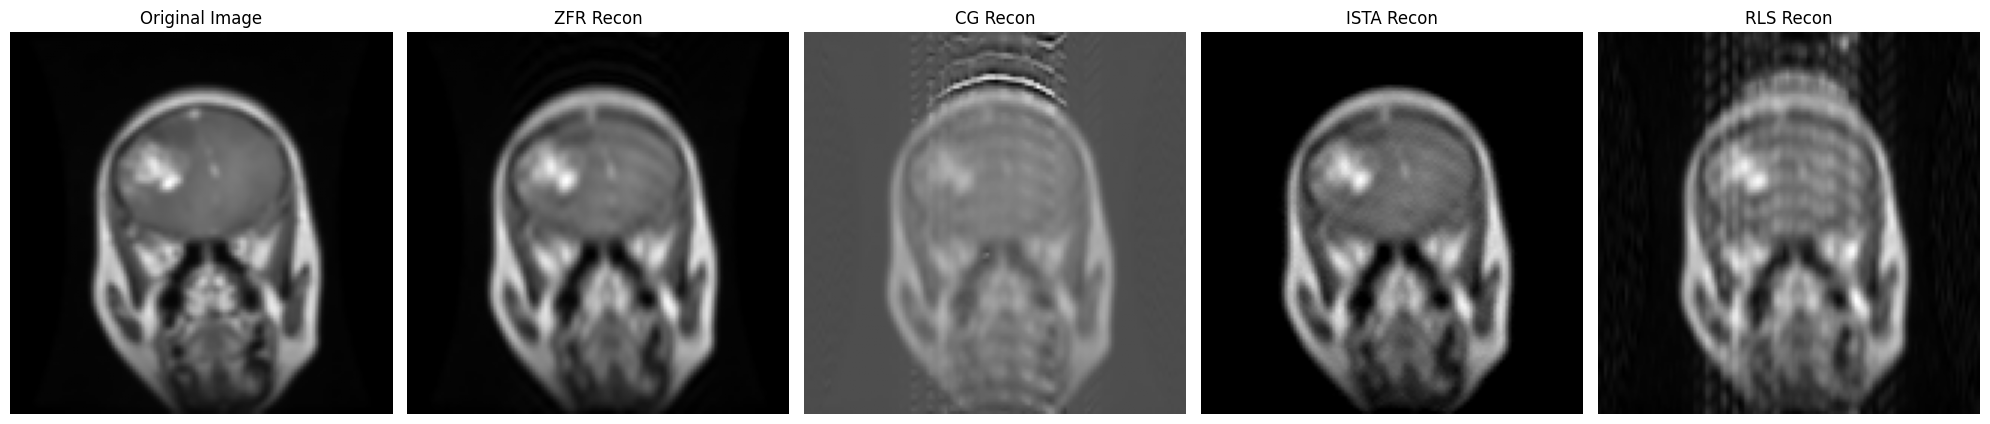

In [14]:


import matplotlib.pyplot as plt

# 8. VISUALIZATION (Updated for RLS)
# ==============================================================================
# Full K-Space Recon of the first image in batch for display
full_recon_img = torch.abs(torch.fft.ifft2(torch.fft.ifftshift(k_space_batch[0]))).cpu().numpy()

plt.figure(figsize=(20, 5)) # Widened the figure to accommodate the 5th image

plt.subplot(1, 5, 1)
plt.imshow(orig_img_cpu, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(zfr_img_cpu, cmap='gray')
plt.title("ZFR Recon")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(cg_img_cpu, cmap='gray')
plt.title("CG Recon")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(ista_img_cpu, cmap='gray')
plt.title("ISTA Recon")
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(rls_img_cpu, cmap='gray')
plt.title("RLS Recon")
plt.axis('off')

plt.tight_layout()
plt.show()
